In [ ]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Install Kaggle Hub

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")

print("Path to dataset files:", path)

100%|██████████| 788M/788M [00:44<00:00, 18.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/versions/1


In [ ]:
import os

print(os.listdir(path))

['readme[1].txt', 'MSR-LA - 3467.docx', 'PetImages']


In [ ]:
base_path = path + "/PetImages"
print(os.listdir(base_path))

['Cat', 'Dog']


In [ ]:
import shutil

os.makedirs("dataset/cat", exist_ok=True)
os.makedirs("dataset/dog", exist_ok=True)

Step 2.3 — Copy images

In [ ]:
# Copy Cat images
for file in os.listdir(base_path + "/Cat")[:1000]:
    try:
        shutil.copy(base_path + "/Cat/" + file, "dataset/cat")
    except:
        pass

# Copy Dog images
for file in os.listdir(base_path + "/Dog")[:1000]:
    try:
        shutil.copy(base_path + "/Dog/" + file, "dataset/dog")
    except:
        pass

Verify

In [ ]:
print("Cat:", len(os.listdir("dataset/cat")))
print("Dog:", len(os.listdir("dataset/dog")))

Cat: 1000
Dog: 1000


Step 3.1 — Import libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
img_size = (128, 128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,          # normalize pixels
    validation_split=0.2     # 80% train, 20% validation
)

In [ ]:
train_data = datagen.flow_from_directory(
    "dataset/",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',     # IMPORTANT (only 2 classes)
    subset='training'
)

Found 1600 images belonging to 2 classes.


In [ ]:
val_data = datagen.flow_from_directory(
    "dataset/",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 400 images belonging to 2 classes.


In [ ]:
print(train_data.class_indices)

{'cat': 0, 'dog': 1}


Step 4 : Build CNN Model

In [ ]:
from tensorflow.keras import layers, models

In [ ]:
model = models.Sequentimodel.summary()al([

    # 🔹 Layer 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    # 🔹 Layer 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # 🔹 Layer 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # 🔹 Flatten
    layers.Flatten(),

    # 🔹 Dense layers
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')   # binary output
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
layers.Dense(1, activation='sigmoid')

<Dense name=dense_2, built=False>

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - accuracy: 0.5306 - loss: 0.6964 - val_accuracy: 0.5675 - val_loss: 0.6824
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.6081 - loss: 0.6525 - val_accuracy: 0.6350 - val_loss: 0.6447
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.6781 - loss: 0.5870 - val_accuracy: 0.6925 - val_loss: 0.6091
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.7219 - loss: 0.5433 - val_accuracy: 0.7000 - val_loss: 0.6089
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.7625 - loss: 0.4803 - val_accuracy: 0.7175 - val_loss: 0.5930
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.8200 - loss: 0.4006 - val_accuracy: 0.7050 - val_loss: 0.6400
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.8562 - loss: 0.3286 - val_accuracy: 0.7275 - val_loss: 0.6634
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.8975 - loss: 0.2535 - val_accuracy: 0.7125 - 

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving catimage.jpeg to catimage.jpeg


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [ ]:
prediction = model.predict(img_array)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[[0.01856232]]


In [ ]:
if prediction[0][0] > 0.5:
    label = "Dog 🐶"
    confidence = prediction[0][0]
else:
    label = "Cat 🐱"
    confidence = 1 - prediction[0][0]

print(f"Prediction: {label}")
print(f"Confidence: {confidence*100:.2f}%")

Prediction: Cat 🐱
Confidence: 98.14%


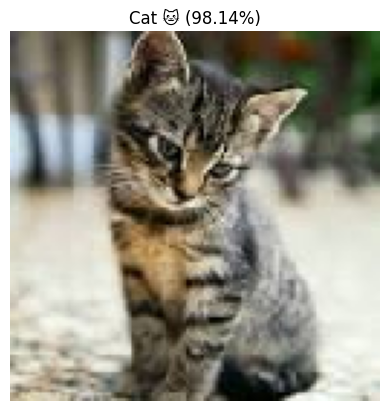

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"{label} ({confidence*100:.2f}%)")
plt.axis('off')
plt.show()

In [ ]:
model.save("cnn_model.h5")

In [ ]:
model.save("cnn_model.keras")

In [ ]:
from google.colab import files
files.download("cnn_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>